In [2]:
import pandas as pd
import numpy as np
import plotly.express as px


In [8]:
import pandas as pd
import plotly.express as px

df = pd.read_excel(
    r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\data\Terror.xlsx",
    sheet_name="Terror_Long_1970_2020"
)

fig = px.choropleth(
    df,
    locations="Country",
    locationmode="country names",
    color="Attacks",
    animation_frame="Year",
    color_continuous_scale="Reds",
    projection="natural earth",
    range_color=(0, df["Attacks"].quantile(0.98)),
    title="Global Terrorism Trend Over Time"
)

# -------------------------
# Black theme styling + canvas size
# -------------------------
fig.update_layout(
    template="plotly_dark",
    paper_bgcolor="black",
    plot_bgcolor="black",
    font=dict(color="white", size=14),
    title=dict(x=0.5, font=dict(size=22)),
    geo=dict(
        bgcolor="black",
        showframe=False,
        showcoastlines=False
    ),
    coloraxis_colorbar=dict(
        title=dict(text="Number of Attacks", font=dict(color="white")),
        tickfont=dict(color="white")
    ),
    width=1200,   # increase width
    height=800    # increase height
)

# -------------------------
# SPEED UP default animation
# -------------------------
fig.layout.updatemenus[0].buttons[0].args[1]["frame"]["duration"] = 300
fig.layout.updatemenus[0].buttons[0].args[1]["transition"]["duration"] = 150

fig.show()


In [10]:
fig.write_html("terrorism_world_animation1.html")


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --------------------------
# Folder to save images
# --------------------------
output_dir = r"C:\Users\DELL\OneDrive\Desktop\Project sem 2\plots"
os.makedirs(output_dir, exist_ok=True)

# --------------------------
# Plot settings
# --------------------------
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "axes.titlesize": 16,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

# --------------------------
# Save separate line plots for each country
# --------------------------
for country in top_10_countries:
    country_df = df_top[df_top["Country"] == country]

    plt.figure(figsize=(12, 6))
    sns.lineplot(
        data=country_df,
        x="Year",
        y="Attacks",
        linewidth=2
    )

    plt.title(f"Terrorist Attacks Over Time: {country}")
    plt.xlabel("Year")
    plt.ylabel("Number of Attacks")
    plt.tight_layout()
    
    # Save as PNG
    filename = os.path.join(output_dir, f"{country}_attacks.png")
    plt.savefig(filename, dpi=300)  # high quality
    plt.close()  # close figure to free memory

print(f"All plots saved in: {output_dir}")


All plots saved in: C:\Users\DELL\OneDrive\Desktop\Project sem 2\plots


Country-wise evolution of terrorist attacks (1970–2020).
Each panel shows the temporal dynamics of attacks for one of the ten most affected countries, highlighting distinct conflict trajectories and peak violence periods.

In [26]:
print(df.columns.tolist())


['Country', 'Year', 'Attacks_x', 'Control of corruption', 'Rule of law', 'Government Effectiveness', 'Political Stability', 'Voice and Accountability', 'Regulatory Quality', 'Attacks_y', 'Control of corruption_scaled', 'Rule of law_scaled', 'Government Effectiveness_scaled', 'Political Stability_scaled', 'Voice and Accountability_scaled', 'Regulatory Quality_scaled']


In [38]:
import geopandas as gpd

url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
world = gpd.read_file(url)

# Check columns
print(world.columns)


Index(['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3',
       'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN',
       ...
       'FCLASS_TR', 'FCLASS_ID', 'FCLASS_PL', 'FCLASS_GR', 'FCLASS_IT',
       'FCLASS_NL', 'FCLASS_SE', 'FCLASS_BD', 'FCLASS_UA', 'geometry'],
      dtype='object', length=169)


In [39]:
import pandas as pd
import geopandas as gpd
from esda.getisord import G_Local
from libpysal.weights import Queen
import pycountry
import geodatasets as gdst  # ✅ new import for world map

# --- 1️⃣ Your terrorism data
# Example columns: Country, Year, Attacks
# gtd_df = pd.read_csv("your_terrorism_data.csv")

# --- 2️⃣ Generate ISO3 codes automatically
def get_iso3(country_name):
    try:
        return pycountry.countries.lookup(country_name).alpha_3
    except:
        return None  # some countries may not be found

gtd_df["ISO3"] = gtd_df["Country"].apply(get_iso3)

# Optional: manually fix missing ISO3 codes
iso_fix = {
    "Palestine": "PSE",
    "Kosovo": "XKX",
    "Russia": "RUS",
    "Vatican City": "VAT",
    "Brunei": "BRN"
}
gtd_df["ISO3"] = gtd_df["ISO3"].fillna(gtd_df["Country"].map(iso_fix))

# --- 3️⃣ Load world shapefile using geodatasets
world = gdst.load_dataset("naturalearth_lowres")  # ✅ updated line

# --- 4️⃣ Filter data for a specific year
year = 2015
geo_df = world.merge(
    gtd_df[gtd_df["Year"] == year],
    left_on="iso_a3",
    right_on="ISO3",
    how="left"
)

# --- 5️⃣ Fill missing attacks with 0
geo_df["Attacks"] = geo_df["Attacks"].fillna(0)

# --- 6️⃣ Compute spatial weights and Gi*
w = Queen.from_dataframe(geo_df)
w.transform = "r"

gi = G_Local(geo_df["Attacks"], w)
geo_df["GiZ"] = gi.Zs

# --- 7️⃣ Plot Gi* hotspot map
geo_df.plot(
    column="GiZ",
    cmap="coolwarm",
    legend=True,
    figsize=(14, 8),
    edgecolor="black"
)


AttributeError: module 'geodatasets' has no attribute 'load_dataset'

C:\Users\DELL\AppData\Local\Temp\ipykernel_32668\2591432312.py:46: FutureWarning:

`use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning:

The weights matrix is not fully connected: 
 There are 25 disconnected components.
 There are 21 islands with ids: 0, 19, 20, 22, 23, 45, 46, 47, 78, 89, 134, 135, 136, 137, 138, 140, 144, 147, 155, 159, 175.

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\esda\getisord.py:527: RuntimeWarning:

invalid value encountered in divide



('WARNING: ', 0, ' is an island (no neighbors)')
('WARNING: ', 19, ' is an island (no neighbors)')
('WARNING: ', 20, ' is an island (no neighbors)')
('WARNING: ', 22, ' is an island (no neighbors)')
('WARNING: ', 23, ' is an island (no neighbors)')
('WARNING: ', 45, ' is an island (no neighbors)')
('WARNING: ', 46, ' is an island (no neighbors)')
('WARNING: ', 47, ' is an island (no neighbors)')
('WARNING: ', 78, ' is an island (no neighbors)')
('WARNING: ', 89, ' is an island (no neighbors)')
('WARNING: ', 134, ' is an island (no neighbors)')
('WARNING: ', 135, ' is an island (no neighbors)')
('WARNING: ', 136, ' is an island (no neighbors)')
('WARNING: ', 137, ' is an island (no neighbors)')
('WARNING: ', 138, ' is an island (no neighbors)')
('WARNING: ', 140, ' is an island (no neighbors)')
('WARNING: ', 144, ' is an island (no neighbors)')
('WARNING: ', 147, ' is an island (no neighbors)')
('WARNING: ', 155, ' is an island (no neighbors)')
('WARNING: ', 159, ' is an island (no neig

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\esda\getisord.py:450: RuntimeWarning:

invalid value encountered in divide



<Axes: >

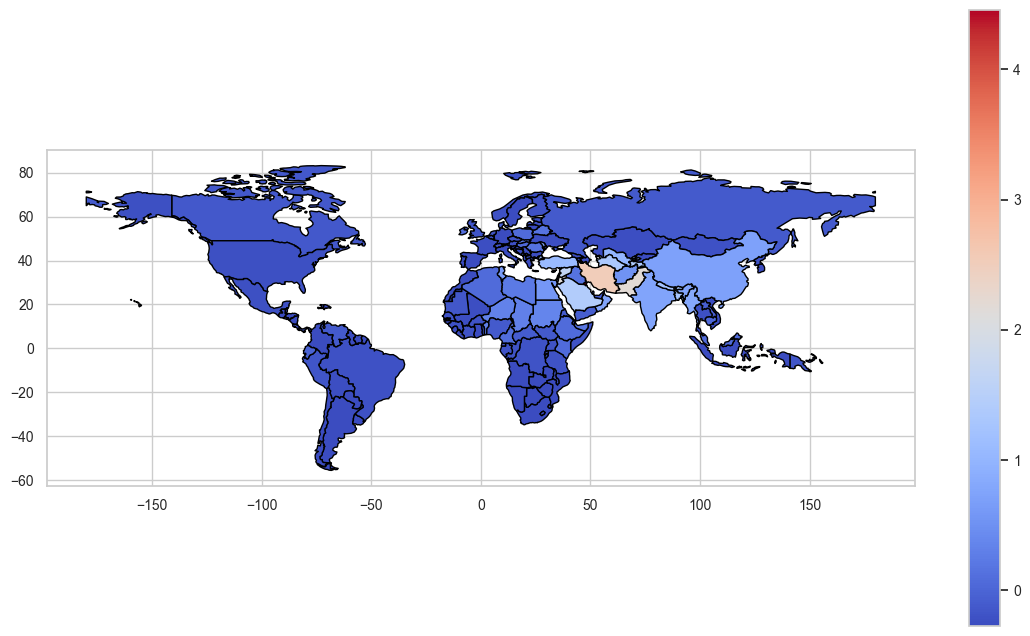

In [40]:
import pandas as pd
import geopandas as gpd
from esda.getisord import G_Local
from libpysal.weights import Queen
import pycountry

# --- 1️⃣ Your terrorism data
# gtd_df = pd.read_csv("your_terrorism_data.csv")

# --- 2️⃣ Generate ISO3 codes automatically
def get_iso3(country_name):
    try:
        return pycountry.countries.lookup(country_name).alpha_3
    except:
        return None

gtd_df["ISO3"] = gtd_df["Country"].apply(get_iso3)

# Optional: manually fix missing ISO3 codes
iso_fix = {
    "Palestine": "PSE",
    "Kosovo": "XKX",
    "Russia": "RUS",
    "Vatican City": "VAT",
    "Brunei": "BRN"
}
gtd_df["ISO3"] = gtd_df["ISO3"].fillna(gtd_df["Country"].map(iso_fix))

# --- 3️⃣ Load world shapefile from GitHub URL
url = "https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson"
world = gpd.read_file(url)

# --- 4️⃣ Filter data for a specific year
year = 2015
geo_df = world.merge(
    gtd_df[gtd_df["Year"] == year],
    left_on="ISO_A3",  # check the ISO3 column name in the geojson
    right_on="ISO3",
    how="left"
)

# --- 5️⃣ Fill missing attacks with 0
geo_df["Attacks"] = geo_df["Attacks"].fillna(0)

# --- 6️⃣ Compute spatial weights and Gi*
w = Queen.from_dataframe(geo_df)
w.transform = "r"

gi = G_Local(geo_df["Attacks"], w)
geo_df["GiZ"] = gi.Zs

# --- 7️⃣ Plot Gi* hotspot map
geo_df.plot(
    column="GiZ",
    cmap="coolwarm",
    legend=True,
    figsize=(14, 8),
    edgecolor="black"
)
